![](https://img.shields.io/badge/CNES_AVISO-Contribution-%20?color=grey&labelColor=blue)

# SWOT L2 KaRIn LR Ocean Data Products

This tutorial will introduce you to some sample SWOT L2 KaRIn LR data products and show you how to download these data from AVISO and perform basic plots using Python related libraries.


<div class="alert alert-info"><b>Note</b><p>

Environment needed to run this notebook:

* ``xarray``
* ``matplotlib``+``cartopy``
* ``altimetry_downloader_aviso``
* ``altimetry.io``
</p></div>

## Tutorial Objectives
* Present SWOT sample L2 KaRIn LR data products (Basic version)
* Download locally SWOT KaRIn (2D swath) data using the ``altimetry_downloader_aviso``
* Show you how to query SWOT Sea Level Anomaly (SLA) data sets using ``altimetry.io``
* How to visualise data using ``matplotlib``

## Import + code



In [1]:
# Install Cartopy with mamba to avoid discrepancies
# ! mamba install -q -c conda-forge cartopy

In [2]:
# Configure logging if you want more details
import logging
logging.basicConfig(level=logging.INFO)

In [3]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cft
import cartopy.mpl.geoaxes as cmplgeo
import cartopy.mpl.gridliner as cmplgrid
import matplotlib.pyplot as plt

%matplotlib inline

## Parameters
Define a local filepath to download files

In [4]:
output_dir= Path.home() / "TMP_DATA"

In [5]:
cycle_number = 34
pass_number = 39

In [6]:
# California
bbox = [233, 35, 237, 42]

## Download data using ``altimetry_downloader_aviso``

In [7]:
import altimetry_downloader_aviso as dl_aviso

### Consult Aviso's catalog

In [8]:
cat = dl_aviso.summary()

INFO:altimetry_downloader_aviso.catalog_client.client:Fetching products from Aviso's catalog...


In [9]:
for product in cat.products:
    print(f"{product.short_name}  {product.title}")

SWOT_L3_LR_WIND_WAVE_Light  Wind & Wave product SWOT Level-3 WindWave - Light
L4_exp_with_SWOT  Experimental Products: Multimission Gridded (with SWOT) Level-4 Sea Surface Heights and Velocities
SWOT_L3_LR_WIND_WAVE_Extended  Wind & Wave product SWOT Level-3 WindWave - Extended
SWOT_L2_LR_SSH_Basic  Altimetry product SWOT Level-2 KaRIn Low Rate SSH - Basic
SWOT_L3_LR_SSH_Expert  Altimetry product SWOT Level-3 Low Rate SSH - Expert
SWOT_L2_LR_SSH_WindWave  Altimetry product SWOT Level-2 KaRIn Low Rate SSH - WindWave
SWOT_L2_LR_SSH_Unsmoothed  Altimetry product SWOT Level-2 KaRIn Low Rate SSH - Unsmoothed
SWOT_L3_LR_SSH_Unsmoothed  Altimetry product SWOT Level-3 Low Rate SSH - Unsmoothed
SWOT_L2_LR_SSH_Expert  Altimetry product SWOT Level-2 KaRIn Low Rate SSH - Expert
SWOT_L3_LR_SSH_Technical  Altimetry product SWOT Level-3 Low Rate SSH - Technical
SWOT_L3_LR_SSH_Basic  Altimetry product SWOT Level-3 Low Rate SSH - Basic


### Download basic half orbit

In [10]:
dl_aviso.get(
    'SWOT_L2_LR_SSH_Basic', 
    output_dir=output_dir, 
    cycle_number=cycle_number, 
    pass_number=pass_number
)

INFO:altimetry_downloader_aviso.catalog_client.client:Fetching products from Aviso's catalog...
INFO:altimetry_downloader_aviso.catalog_client.granule_discoverer:Filtering SWOT_L2_LR_SSH_Basic product with filters {'cycle_number': 34, 'pass_number': 39}...
INFO:altimetry_downloader_aviso.core:1 files to download. 0 files already exist.
INFO:altimetry_downloader_aviso.tds_client:File /home/atonneau/TMP_DATA/SWOT_L2_LR_SSH_Basic_034_039_20250610T025623_20250610T034710_PID0_01.nc downloaded.


['/home/atonneau/TMP_DATA/SWOT_L2_LR_SSH_Basic_034_039_20250610T025623_20250610T034710_PID0_01.nc']

## Open a data subset using ``altimetry.io``

In [11]:
from altimetry.io import AltimetryData, FileCollectionSource

Select regional boundaries

In [12]:
from shapely.geometry import Polygon
lon_min, lat_min, lon_max, lat_max = bbox
polygon = Polygon([
    (lon_min, lat_min),
    (lon_min, lat_max),
    (lon_max, lat_max),
    (lon_max, lat_min),
    (lon_min, lat_min),
])

Open data source

In [13]:
alti_data = AltimetryData(
    source=FileCollectionSource(
        path=output_dir,
        ftype="SWOT_L2_LR_SSH",
        subset="Basic"
    ),
)

Query data with half orbit with geographical selection

In [14]:
ds_basic = alti_data.query_orbit( 
    cycles_nb=cycle_number, 
    passes_nb=pass_number,
    polygon=polygon
)

INFO:fcollections.implementations.optional._predicates:The bbox intersects with pass numbers (calval phase): [13, 26]
INFO:fcollections.implementations.optional._predicates:The bbox intersects with pass numbers (science phase): [11, 24, 39, 52, 67, 302, 317, 330, 345, 358, 373, 580]
INFO:fcollections.core._readers:Files to read: 1
INFO:fcollections.implementations.optional._area_selectors:Size of the dataset matching the bbox: {'num_lines': 410, 'num_pixels': 69, 'num_sides': 2}


In [15]:
ds_basic

<xarray.Dataset> Size: 5MB
Dimensions:                                (num_lines: 410, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    time                                   (num_lines) datetime64[ns] 3kB dask.array<chunksize=(410,), meta=np.ndarray>
    latitude                               (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    longitude                              (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/25)
    time_tai                               (num_lines) datetime64[ns] 3kB dask.array<chunksize=(410,), meta=np.ndarray>
    ssh_karin                              (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ssh_karin_qual                         (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ssh_karin_uncert                       (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ssha_karin                             (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ssha_karin_qual                        (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ...                                     ...
    geoid                                  (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    internal_tide_hret                     (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    height_cor_xover                       (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    height_cor_xover_qual                  (num_lines, num_pixels) float32 113kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    cycle_number                           (num_lines) uint16 820B 34 34 ... 34
    pass_number                            (num_lines) uint16 820B 39 39 ... 39
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2025-06-12T22:07:03Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       64.45744266445926
    ssha_variance:                                 2.3281695511349625
    references:                                    V1.4.1
    equator_longitude:                             -131.75

## Discover SWOT L2 KaRIn Ocean Basic product


### Basic product content
This product contains two versions of SLA (ssha in the datasets) with different wet troposhere and sea state bias (SSB) corrections:
- ssha_karin relies more on observations (e.g., wet tropo corrected using radiometer data)
- ssha_karin_2 relies more on model for corrections (e.g., wet tropo corrected using ECMWF model)


In [16]:
[v for v in ds_basic.variables]

['time',
 'time_tai',
 'ssh_karin',
 'ssh_karin_qual',
 'ssh_karin_uncert',
 'ssha_karin',
 'ssha_karin_qual',
 'ssh_karin_2',
 'ssh_karin_2_qual',
 'ssha_karin_2',
 'ssha_karin_2_qual',
 'num_pt_avg',
 'distance_to_coast',
 'heading_to_coast',
 'ancillary_surface_classification_flag',
 'dynamic_ice_flag',
 'rain_flag',
 'rad_surface_type_flag',
 'mean_sea_surface_cnescls',
 'mean_sea_surface_cnescls_uncert',
 'geoid',
 'internal_tide_hret',
 'height_cor_xover',
 'height_cor_xover_qual',
 'latitude',
 'longitude',
 'cycle_number',
 'pass_number']

### Application of Crossover Calibration Correction (XOverCal or xover)
To get corrected SSHA, user must apply the xover as follows:
- ssha_karin_corrected = ssha_karin + height_cor_xover
- ssha_karin_2_corrected = ssha_karin_2 + height_cor_xover

In [17]:
ds_basic['ssha_karin_corrected'] = ds_basic.ssha_karin + ds_basic.height_cor_xover
ds_basic['ssha_karin_2_corrected'] = ds_basic.ssha_karin_2 + ds_basic.height_cor_xover
ds_basic

<xarray.Dataset> Size: 5MB
Dimensions:                                (num_lines: 410, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    time                                   (num_lines) datetime64[ns] 3kB dask.array<chunksize=(410,), meta=np.ndarray>
    latitude                               (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    longitude                              (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/27)
    time_tai                               (num_lines) datetime64[ns] 3kB dask.array<chunksize=(410,), meta=np.ndarray>
    ssh_karin                              (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ssh_karin_qual                         (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ssh_karin_uncert                       (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ssha_karin                             (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ssha_karin_qual                        (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ...                                     ...
    height_cor_xover                       (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    height_cor_xover_qual                  (num_lines, num_pixels) float32 113kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    cycle_number                           (num_lines) uint16 820B 34 34 ... 34
    pass_number                            (num_lines) uint16 820B 39 39 ... 39
    ssha_karin_corrected                   (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
    ssha_karin_2_corrected                 (num_lines, num_pixels) float64 226kB dask.array<chunksize=(410, 69), meta=np.ndarray>
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2025-06-12T22:07:03Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       64.45744266445926
    ssha_variance:                                 2.3281695511349625
    references:                                    V1.4.1
    equator_longitude:                             -131.75

Mask invalid data


In [18]:
ds_basic["ssha_karin_corrected"] = ds_basic.ssha_karin_corrected.where(ds_basic.ancillary_surface_classification_flag==0)
ds_basic["ssha_karin_corrected"] = ds_basic.ssha_karin_corrected.where(ds_basic.ssha_karin_qual==0)

In [19]:
ds_basic["ssha_karin_2_corrected"] = ds_basic.ssha_karin_2_corrected.where(ds_basic.ancillary_surface_classification_flag==0)
ds_basic["ssha_karin_2_corrected"] = ds_basic.ssha_karin_2_corrected.where(ds_basic.ssha_karin_2_qual==0)

### Output visualisation: basic SLA plots


Let's visualise SWOT KaRIn LR data using cartopy

Text(0.5, 1.0, 'SSHA KaRIn 2 corrected')

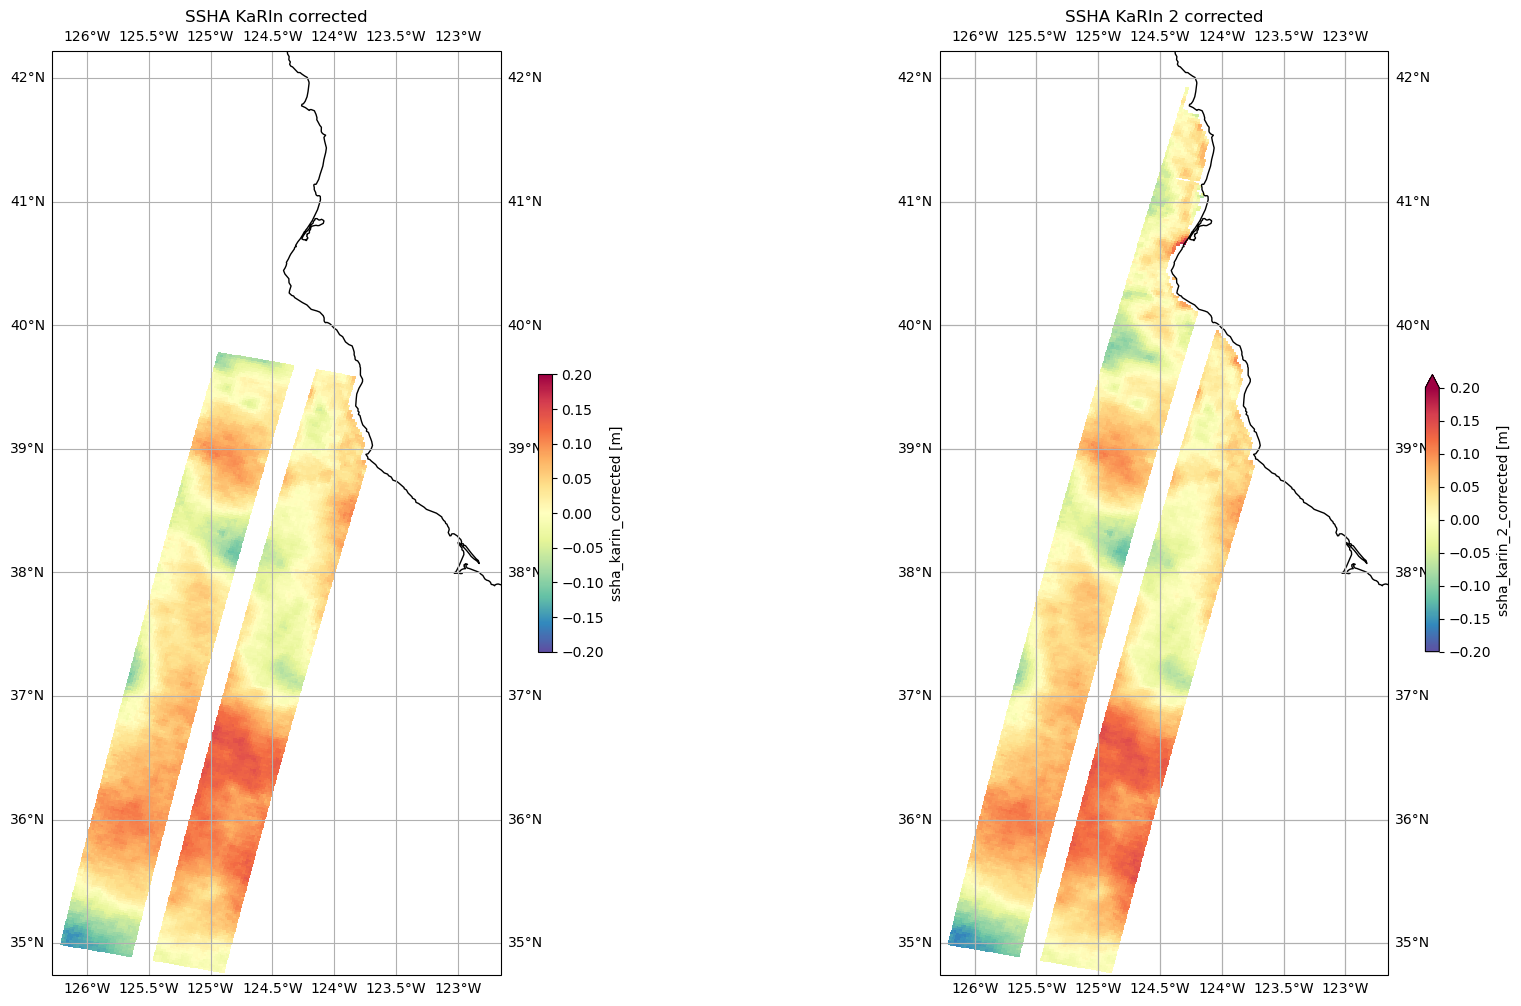

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))
plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="Spectral_r",
    vmin=-0.2,
    vmax=0.2,
    cbar_kwargs={"shrink": 0.3},)

# SWOT KaRIn SLA plots
ds_basic.ssha_karin_corrected.plot.pcolormesh(ax=ax1, **plot_kwargs)
ds_basic.ssha_karin_2_corrected.plot.pcolormesh(ax=ax2, **plot_kwargs)

ax1.gridlines(draw_labels=True)
ax1.coastlines()
ax2.gridlines(draw_labels=True)
ax1.set_title("SSHA KaRIn corrected")
ax2.coastlines()
ax2.gridlines()
ax2.set_title("SSHA KaRIn 2 corrected")